In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [8]:
# load the dataset
path_to_data = Path().cwd().parent / 'dataset'

original_df = pd.read_csv(path_to_data / 'train.csv')
preprocessed_df = pd.read_csv(path_to_data / 'preprocessed_train.csv')

In [9]:
original_df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [10]:
preprocessed_df.head()

,amount_tsh,gps_height,longitude,latitude,population,construction_year,status_group,basin_Internal,basin_Lake Nyasa,basin_Lake Rukwa,...,waterpoint_type_improved spring,waterpoint_type_other,funder_frequency,installer_frequency,lga_frequency,year_recorded,month_recorded,geo_cluster,pump_age,geo_cluster_source
0,1.389293,0.388727,-0.005410,-0.927176,-0.376880,1999.0,functional,0,1,0,...,0,0,57.52,50.47,64.48,2011,3,7,12.0,0.790486
1,-0.398433,0.406220,-0.067652,0.551184,0.209470,2010.0,functional,0,0,0,...,0,0,57.52,50.47,64.48,2013,3,6,3.0,0.595878
2,-0.992374,-0.979592,0.650639,0.230180,0.138885,2009.0,functional,0,0,0,...,0,0,57.52,50.47,64.48,2013,2,9,4.0,0.519401
3,-0.697497,-1.801749,0.917341,-1.176286,-0.766338,1986.0,non functional,0,0,0,...,0,0,1.78,50.47,64.48,2013,1,8,27.0,0.403482
4,0.000000,0.000000,-0.995565,0.612956,0.000000,1986.0,functional,0,0,0,...,0,0,57.52,50.47,1.30,2011,7,1,25.0,0.645552


In [11]:
# ill start by 3 plans for the data
# 1. use the preprocessed data and apply a simple model to it
# 2. remove the redundant features and apply a simple model to the original data
# 3. find which one is better and then create a full pipeline for it (to avoid data leakage) since we wont have to preprocess the testing data too

In [12]:
# first split the data
from sklearn.model_selection import train_test_split

X = preprocessed_df.drop(columns=['status_group'])
y = preprocessed_df['status_group']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)   # we use stratification to ensure that the 
# splitting distributes the classes in the target variable in equal proportions in the training and testing sets.

In [25]:
# models to try
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
# we need to encode the target variable since some models require it to be in numerical format
from sklearn.preprocessing import LabelEncoder

lr_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', LogisticRegression(max_iter=10000, random_state=42))
])

target_mapping = {'functional': 0, 'functional needs repair': 1, 'non functional': 2}
y_train_encoded = y_train.map(target_mapping)

rf_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

# baseline models to try (pre-hyperparameter tuning)
models = {
    # linear models
    'Logistic Regression': lr_pipeline,

    # nearest neighbors is a simple model can perform well
    # however will take time to train and predict because of the size of the data
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),

    # tree models
    'Random Forest': rf_pipeline,
    'XGBoost': XGBClassifier(random_state=42),
}

In [26]:
# import the evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# initialize a confusion matrix dictionary to store the confusion matrix for each model
confusion_matrices = {}
accuracy_scores = {}

In [27]:
for name, model in models.items():
    print('='*50)

    print(f"Training {name}...")
    model.fit(X_train, y_train_encoded)

    print(f"Evaluating {name}...")

    y_pred = model.predict(X_test)

    # unmap the predicted labels back to their original string format
    inverse_target_mapping = {v: k for k, v in target_mapping.items()}
    y_pred = pd.Series(y_pred).map(inverse_target_mapping)

    
    # save outputs
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    accuracy_scores[name] = accuracy_score(y_test, y_pred)
    
    # print the evaluation metrics
    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix for {name}:\n{confusion_matrices[name]}")
    print(f"Accuracy for {name}: {accuracy_scores[name]}")

Training Logistic Regression...
Evaluating Logistic Regression...
Classification Report for Logistic Regression:
                         precision    recall  f1-score   support

             functional       0.72      0.89      0.80      6452
functional needs repair       0.43      0.06      0.11       863
         non functional       0.78      0.64      0.70      4565

               accuracy                           0.74     11880
              macro avg       0.64      0.53      0.54     11880
           weighted avg       0.72      0.74      0.71     11880

Confusion Matrix for Logistic Regression:
[[5761   41  650]
 [ 644   54  165]
 [1618   30 2917]]
Accuracy for Logistic Regression: 0.735016835016835
Training K-Nearest Neighbors...
Evaluating K-Nearest Neighbors...
Classification Report for K-Nearest Neighbors:
                         precision    recall  f1-score   support

             functional       0.76      0.86      0.81      6452
functional needs repair       0.48  

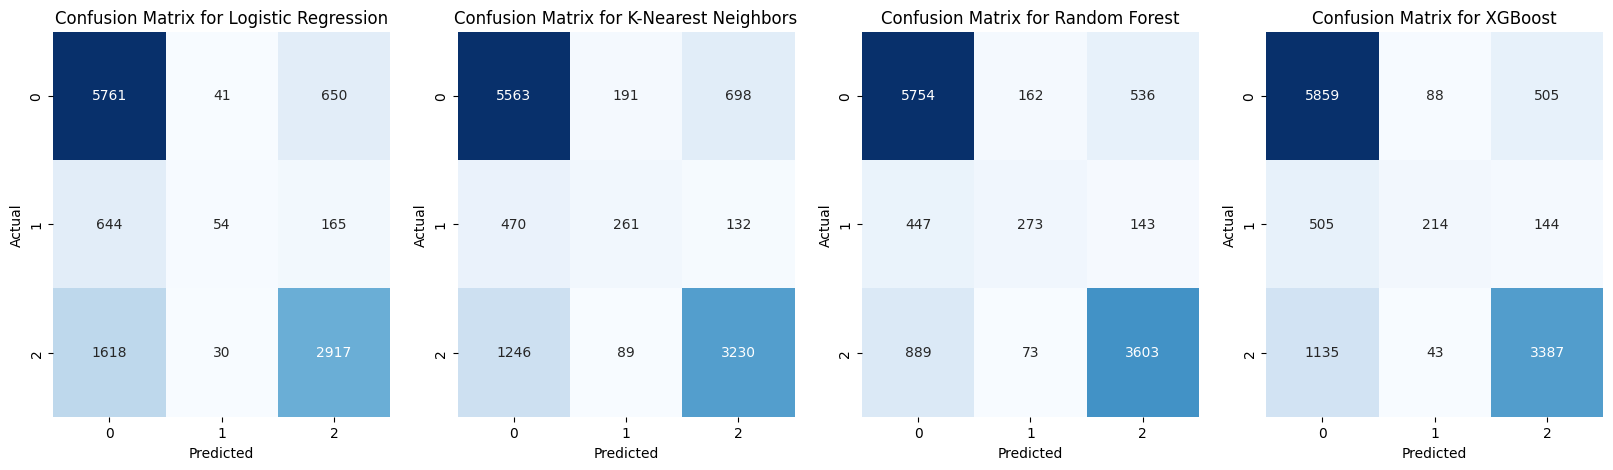

In [29]:
# lets visualize the confusion matrices

plt.figure(figsize=(20, 5))
for i, (name, cm) in enumerate(confusion_matrices.items()):
    plt.subplot(1, len(confusion_matrices), i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.show()

In [31]:
# lets try dropping the redundant features and retraining the same models again

# from previous notebook
# try to drop latitude and longtitude if u will keep geo clusters to avoid redundant features
# also try to drop the year_recorded and construction_year if u will keep pump_age
# and try to drop source if u will keep geo_cluster_source 

preprocessed_df_reduced = preprocessed_df.drop(columns=['latitude', 'longitude', 'year_recorded', 'month_recorded', 'construction_year'])

In [32]:
# again split the data here
X_reduced = preprocessed_df_reduced.drop(columns=['status_group'])
y_reduced = preprocessed_df_reduced['status_group']

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_reduced, test_size=0.2, random_state=42, stratify=y_reduced)

In [33]:
for name, model in models.items():
    print('='*50)

    print(f"Training {name} on reduced data...")
    model.fit(X_train, y_train_encoded)

    print(f"Evaluating {name} on reduced data...")

    y_pred = model.predict(X_test)

    # unmap the predicted labels back to their original string format
    inverse_target_mapping = {v: k for k, v in target_mapping.items()}
    y_pred = pd.Series(y_pred).map(inverse_target_mapping)

    
    # save outputs
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    accuracy_scores[name] = accuracy_score(y_test, y_pred)
    
    # print the evaluation metrics
    print(f"Classification Report for {name} on reduced data:\n{classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix for {name} on reduced data:\n{confusion_matrices[name]}")
    print(f"Accuracy for {name} on reduced data: {accuracy_scores[name]}")

Training Logistic Regression on reduced data...
Evaluating Logistic Regression on reduced data...
Classification Report for Logistic Regression on reduced data:
                         precision    recall  f1-score   support

             functional       0.72      0.89      0.80      6452
functional needs repair       0.41      0.06      0.11       863
         non functional       0.78      0.64      0.70      4565

               accuracy                           0.73     11880
              macro avg       0.64      0.53      0.54     11880
           weighted avg       0.72      0.73      0.71     11880

Confusion Matrix for Logistic Regression on reduced data:
[[5759   46  647]
 [ 644   54  165]
 [1624   31 2910]]
Accuracy for Logistic Regression on reduced data: 0.7342592592592593
Training K-Nearest Neighbors on reduced data...
Evaluating K-Nearest Neighbors on reduced data...
Classification Report for K-Nearest Neighbors on reduced data:
                         precision    

In [ ]:
# as we can see the keeping the redundant features did improve the performance of the models
# lets try removing only the longtitude and latitude

In [36]:
preprocessed_df_reduced_2 = preprocessed_df.drop(columns=['latitude', 'longitude'])

X_reduced_2 = preprocessed_df_reduced_2.drop(columns=['status_group'])
y_reduced_2 = preprocessed_df_reduced_2['status_group']

X_train, X_test, y_train, y_test = train_test_split(X_reduced_2, y_reduced_2, test_size=0.2, random_state=42, stratify=y_reduced_2)

In [37]:
for name, model in models.items():
    print('='*50)

    print(f"Training {name} on reduced data...")
    model.fit(X_train, y_train_encoded)

    print(f"Evaluating {name} on reduced data...")

    y_pred = model.predict(X_test)

    # unmap the predicted labels back to their original string format
    inverse_target_mapping = {v: k for k, v in target_mapping.items()}
    y_pred = pd.Series(y_pred).map(inverse_target_mapping)

    
    # save outputs
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    accuracy_scores[name] = accuracy_score(y_test, y_pred)
    
    # print the evaluation metrics
    print(f"Classification Report for {name} on reduced data:\n{classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix for {name} on reduced data:\n{confusion_matrices[name]}")
    print(f"Accuracy for {name} on reduced data: {accuracy_scores[name]}")

Training Logistic Regression on reduced data...
Evaluating Logistic Regression on reduced data...
Classification Report for Logistic Regression on reduced data:
                         precision    recall  f1-score   support

             functional       0.72      0.89      0.80      6452
functional needs repair       0.41      0.06      0.11       863
         non functional       0.78      0.64      0.70      4565

               accuracy                           0.74     11880
              macro avg       0.64      0.53      0.54     11880
           weighted avg       0.72      0.74      0.71     11880

Confusion Matrix for Logistic Regression on reduced data:
[[5764   42  646]
 [ 647   52  164]
 [1612   32 2921]]
Accuracy for Logistic Regression on reduced data: 0.7354377104377104
Training K-Nearest Neighbors on reduced data...
Evaluating K-Nearest Neighbors on reduced data...
Classification Report for K-Nearest Neighbors on reduced data:
                         precision    

In [ ]:
# again tree models performed better when we kept the redundant features

In [38]:
# lets get back to training on the full preprocessed data

X = preprocessed_df.drop(columns=['status_group'])
y = preprocessed_df['status_group']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [39]:
for name, model in models.items():
    print('='*50)

    print(f"Training {name} on reduced data...")
    model.fit(X_train, y_train_encoded)

    print(f"Evaluating {name} on reduced data...")

    y_pred = model.predict(X_test)

    # unmap the predicted labels back to their original string format
    inverse_target_mapping = {v: k for k, v in target_mapping.items()}
    y_pred = pd.Series(y_pred).map(inverse_target_mapping)

    
    # save outputs
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    accuracy_scores[name] = accuracy_score(y_test, y_pred)
    
    # print the evaluation metrics
    print(f"Classification Report for {name} on reduced data:\n{classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix for {name} on reduced data:\n{confusion_matrices[name]}")
    print(f"Accuracy for {name} on reduced data: {accuracy_scores[name]}")

Training Logistic Regression on reduced data...
Evaluating Logistic Regression on reduced data...
Classification Report for Logistic Regression on reduced data:
                         precision    recall  f1-score   support

             functional       0.72      0.89      0.80      6452
functional needs repair       0.43      0.06      0.11       863
         non functional       0.78      0.64      0.70      4565

               accuracy                           0.74     11880
              macro avg       0.64      0.53      0.54     11880
           weighted avg       0.72      0.74      0.71     11880

Confusion Matrix for Logistic Regression on reduced data:
[[5761   41  650]
 [ 644   54  165]
 [1618   30 2917]]
Accuracy for Logistic Regression on reduced data: 0.735016835016835
Training K-Nearest Neighbors on reduced data...
Evaluating K-Nearest Neighbors on reduced data...
Classification Report for K-Nearest Neighbors on reduced data:
                         precision    r

Feature importance for Random Forest:
[1.85260182e-02 5.63929322e-02 1.12991784e-01 1.13254917e-01
 4.17841876e-02 4.00177648e-02 3.52125098e-03 2.49515404e-03
 2.36578306e-03 2.85961781e-03 2.75503868e-03 2.26734942e-03
 2.76125109e-03 1.64704902e-03 2.59819173e-03 1.52151326e-03
 2.96756122e-04 1.47642952e-03 3.99521560e-03 1.04789516e-03
 1.54715629e-03 1.74005698e-03 9.70345685e-04 1.02352437e-03
 1.54157709e-03 1.24100061e-03 1.61748517e-03 1.04071963e-03
 1.23099558e-03 1.01334594e-03 1.05077442e-03 1.08373302e-03
 1.94340556e-03 1.15057011e-03 6.86607303e-04 1.37271142e-03
 6.08904928e-03 6.04814734e-03 2.13252674e-03 1.66339035e-04
 4.98267419e-05 4.69671829e-03 2.18392591e-03 3.37798034e-04
 2.13752551e-03 1.96785189e-03 5.59768295e-03 2.03182761e-02
 4.44505936e-06 1.29988126e-04 4.35144899e-04 4.88005025e-04
 2.56829644e-03 3.21606973e-03 1.50690742e-04 2.21411222e-04
 5.90966837e-03 6.14710910e-03 2.55100080e-03 1.69223988e-02
 4.76136101e-04 2.71010744e-03 2.29567950e-04 1

<Axes: >

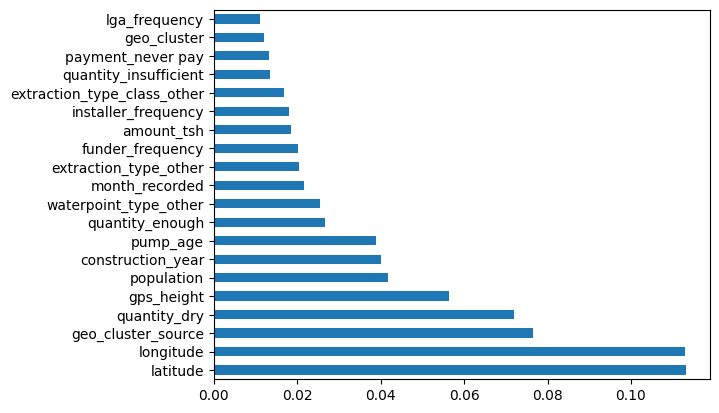

In [43]:
# now lets look at the feature importance for the tree models to see which features are the most important for the predictions

print("Feature importance for Random Forest:")
print(models['Random Forest']['model'].feature_importances_)

importances = pd.Series(models['Random Forest']['model'].feature_importances_, index=X.columns)
importances.nlargest(20).plot(kind='barh')

In [ ]:
# as we can see the results show that the best features are usually the ones related to locations
# which shows that the way to win this competition is to handle spatial and locations features complexity
# another this is that the age, geo_cluster_source showed to be some really good features
# and geo cluster is kinda meh which shows that the geo_cluster feature we synthesized using kmeans clustering ALONE is not enough but with source 
# it adds lots of value even logically as location and source of water the water pump is using are really important features 
# they indicate the enviromental conditions